In [2]:
%cd '/home/julia/Music/diploma/Rhythm_first_AMT'

/home/julia/Music/diploma/Rhythm_first_AMT


In [3]:
# %pip install tf-keras

In [4]:
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from tf_keras import layers, models
import pandas as pd

I0000 00:00:1778867307.053765    6964 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778867307.801113    6964 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778867309.364725    6964 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [5]:
import zipfile, os, shutil, sys, tempfile, subprocess, pretty_midi, librosa, numpy as np
from modules.global_vars import *
from modules.help_funcs import get_X_data, get_y_data

/home/julia/Music/diploma/Rhythm_first_AMT/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
def midi_to_notes(midi_data, start=0, end=None):

    notes = []

    # Iterate through instruments
    for instrument in midi_data.instruments:
        
        # Iterate through notes of each instrument
        for note in instrument.notes:
            if note.start >= start and (end is None or note.start < end):
                notes.append({
                    'pitch': note.pitch,  # MIDI number
                    'onset': note.start - start,
                    'offset': note.end - start
                })
    
    return notes


def midi_to_audio(midi_path, soundfont_path, sr):
        
        with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as tmp_wav:
            tmp_path = tmp_wav.name

        command = [
            'fluidsynth', '-ni',
            str(soundfont_path),
            str(midi_path),
            '-F', tmp_path,
            '-r', str(sr),
            '-q'
        ]

        try:
            subprocess.run(command, check=True, capture_output=True)
            audio, _ = librosa.load(tmp_path, sr=sr, mono=True)
        finally:
            if os.path.exists(tmp_path):
                os.unlink(tmp_path)

        return audio

In [7]:
# soundfont_path = "FluidR3_GM.sf2"
midi_dir = 'maestro_data_from_kaggle'

In [8]:
# import zipfile

# for f in os.listdir(midi_dir):
#     if f.endswith('.zip'):
#         path = f'{midi_dir}/{f}'
#         with zipfile.ZipFile(path, 'r') as zip_ref:
#             zip_ref.extractall(midi_dir)
#         os.remove(path)


In [9]:
file_names = sorted(set([
    s.split('.')[0] for s in os.listdir(midi_dir) if s.endswith('.midi')
]))
np.random.seed(42)
np.random.shuffle(file_names)

file_names

['MIDI-Unprocessed_02_R1_2009_03-06_ORIG_MID--AUDIO_02_R1_2009_02_R1_2009_04_WAV',
 'MIDI-UNPROCESSED_01-03_R1_2014_MID--AUDIO_01_R1_2014_wav--2',
 'MIDI-Unprocessed_02_R1_2006_01-04_ORIG_MID--AUDIO_02_R1_2006_01_Track01_wav',
 'MIDI-Unprocessed_02_R1_2009_03-06_ORIG_MID--AUDIO_02_R1_2009_02_R1_2009_05_WAV',
 'MIDI-Unprocessed_01_R1_2011_MID--AUDIO_R1-D1_05_Track05_wav',
 'MIDI-Unprocessed_02_R1_2009_01-02_ORIG_MID--AUDIO_02_R1_2009_02_R1_2009_02_WAV',
 'MIDI-Unprocessed_01_R1_2006_01-09_ORIG_MID--AUDIO_01_R1_2006_05_Track05_wav',
 'MIDI-Unprocessed_SMF_07_R1_2004_01_ORIG_MID--AUDIO_07_R1_2004_06_Track06_wav',
 'MIDI-UNPROCESSED_01-03_R1_2014_MID--AUDIO_02_R1_2014_wav--4',
 'MIDI-Unprocessed_01_R1_2008_01-04_ORIG_MID--AUDIO_01_R1_2008_wav--2',
 'MIDI-Unprocessed_043_PIANO043_MID--AUDIO-split_07-06-17_Piano-e_1-03_wav--2',
 'MIDI-Unprocessed_02_R1_2011_MID--AUDIO_R1-D1_09_Track09_wav',
 'MIDI-Unprocessed_SMF_05_R1_2004_02-03_ORIG_MID--AUDIO_05_R1_2004_06_Track06_wav',
 'MIDI-Unprocessed

In [10]:
midi_dir2 = 'maestro_data_test_cut'

In [11]:
df_audio_f_name = 'audio.csv'
midi_dir3 = 'maestro_data_test_full'

In [12]:
# import soundfile as sf

# for i in range(10):
#     y_init, sr_init = librosa.load(f'{midi_dir}/{file_names[i]}.mp3')
#     sf.write(f'{midi_dir2}/{file_names[i]}.mp3', y_init[:60 * SR], SR)
#     shutil.copy2(f'{midi_dir}/{file_names[i]}.midi', midi_dir2)
#     shutil.copy2(f'{midi_dir}/{file_names[i]}.mp3', midi_dir3)
#     os.remove(f'{midi_dir}/{file_names[i]}.mp3')
#     os.remove(f'{midi_dir}/{file_names[i]}.midi')

In [13]:
file_names2 = [
    s.split('.')[0] for s in os.listdir(midi_dir2) if s.endswith('.mp3')
]
file_names2

['MIDI-Unprocessed_02_R1_2006_01-04_ORIG_MID--AUDIO_02_R1_2006_02_Track02_wav',
 'MIDI-UNPROCESSED_01-03_R1_2014_MID--AUDIO_02_R1_2014_wav--1',
 'MIDI-Unprocessed_01_R1_2011_MID--AUDIO_R1-D1_03_Track03_wav',
 'MIDI-Unprocessed_01_R2_2006_01_ORIG_MID--AUDIO_01_R2_2006_03_Track03_wav',
 'ORIG-MIDI_01_7_10_13_Group_MID--AUDIO_02_R3_2013_wav--1',
 'MIDI-Unprocessed_01_R1_2009_01-04_ORIG_MID--AUDIO_01_R1_2009_01_R1_2009_01_WAV',
 'MIDI-Unprocessed_02_R1_2008_01-05_ORIG_MID--AUDIO_02_R1_2008_wav--1',
 'MIDI-Unprocessed_01_R1_2006_01-09_ORIG_MID--AUDIO_01_R1_2006_03_Track03_wav',
 'MIDI-UNPROCESSED_01-03_R1_2014_MID--AUDIO_01_R1_2014_wav--1',
 'MIDI-Unprocessed_01_R1_2006_01-09_ORIG_MID--AUDIO_01_R1_2006_01_Track01_wav']

In [14]:
np.intersect1d(file_names, file_names2)

array([], dtype='<U79')

In [15]:
train_test_midi = file_names
test_midi = file_names2

In [16]:
cqt_len = DELTA_PRED + DELTA_POST + 1

In [17]:
def add_data_to_arrs(diff_cqt_data, piano_notes_data, train_test_midi):
    for iter, f in enumerate(train_test_midi):
        sys.stdout.write(f'\r Iteration {iter+1}/{len(train_test_midi)}')
        sys.stdout.flush()
        midi_path = f'{midi_dir}/{f}.midi'
        mp3_path = f'{midi_dir}/{f}.mp3'
        midi_data = pretty_midi.PrettyMIDI(midi_path)
        y_init, sr_init = librosa.load(mp3_path)
        y = librosa.resample(y=y_init, orig_sr=sr_init, target_sr=SR)
        cqt = np.abs(librosa.cqt(y, sr=SR, fmin=NOTE_A_MIN, n_bins=N_BINS, bins_per_octave=BINS_PER_OCT,
                                hop_length=HOP_LENGTH)).T
        cqt = np.concat([np.zeros((DELTA_PRED, cqt.shape[1])), cqt, np.zeros((DELTA_POST + 1, cqt.shape[1]))])
        diff_cqt = np.maximum(0, np.diff(cqt, axis=0))
        
        notes = midi_to_notes(midi_data=midi_data)
        notes_ons = librosa.time_to_frames([note['onset'] for note in notes], sr=SR, hop_length=HOP_LENGTH)
        piano_roll_ons = np.zeros((cqt.shape[0], NOTES_COUNT))
        
        for ons, n in zip(notes_ons, notes):
            piano_roll_ons[ons + DELTA_PRED, n['pitch'] - 21] = 1

        np.random.seed(42)
        notes_ons = np.array(list(set(notes_ons)))
        np.random.shuffle(notes_ons)
        
        for ons in notes_ons[:]:
            diff_cqt_data.append(diff_cqt[ons : ons + cqt_len])
            piano_notes_data.append(piano_roll_ons[ons : ons + cqt_len])

In [18]:
diff_cqt_data = []
piano_notes_data = []

In [19]:
# add_data_to_arrs(diff_cqt_data, piano_notes_data, train_test_midi[:20])

In [20]:
# add_data_to_arrs(diff_cqt_data, piano_notes_data, train_test_midi[20:40])

In [21]:
# add_data_to_arrs(diff_cqt_data, piano_notes_data, train_test_midi[40:60])

In [22]:
# add_data_to_arrs(diff_cqt_data, piano_notes_data, train_test_midi[60:])

In [23]:
diff_cqt_data = np.array(diff_cqt_data)
piano_notes_data = np.array(piano_notes_data)

In [24]:
# diff_cqt_data.shape[0] / len(train_test_midi)

In [25]:
diff_cqt_data_test = []
piano_notes_data_test = []
start, end = 0, 60
files_and_moments = []

for iter, f in enumerate(test_midi):
    sys.stdout.write(f'\r Iteration {iter+1}/{len(test_midi)}')
    sys.stdout.flush()
    midi_path = f'{midi_dir2}/{f}.midi'
    mp3_path = f'{midi_dir2}/{f}.mp3'
    midi_data = pretty_midi.PrettyMIDI(midi_path)
    y_init, sr_init = librosa.load(mp3_path)
    y = librosa.resample(y=y_init, orig_sr=sr_init, target_sr=SR)
    cqt = np.abs(librosa.cqt(y, sr=SR, fmin=NOTE_A_MIN, n_bins=N_BINS, bins_per_octave=BINS_PER_OCT,
                             hop_length=HOP_LENGTH)).T
    cqt = np.concat([np.zeros((DELTA_PRED, cqt.shape[1])), cqt, np.zeros((DELTA_POST + 1, cqt.shape[1]))])
    diff_cqt = np.maximum(0, np.diff(cqt, axis=0))
    
    notes = midi_to_notes(midi_data=midi_data, start=start, end=end)
    notes_ons_time = [note['onset'] for note in notes]
    notes_ons = librosa.time_to_frames(notes_ons_time, sr=SR, hop_length=HOP_LENGTH)
    piano_roll_ons = np.zeros((cqt.shape[0], NOTES_COUNT))

    for ons, n in zip(notes_ons, notes):
        piano_roll_ons[ons + DELTA_PRED, n['pitch'] - 21] = 1
    
    for ons in set(notes_ons):
        diff_cqt_data_test.append(diff_cqt[ons : ons + cqt_len])
        piano_notes_data_test.append(piano_roll_ons[ons : ons + cqt_len])

        files_and_moments.append((f, librosa.frames_to_samples(ons)))
    
diff_cqt_data_test = np.array(diff_cqt_data_test)
piano_notes_data_test = np.array(piano_notes_data_test)

 Iteration 10/10

In [26]:
# from IPython.display import Audio
# Audio(y[:librosa.frames_to_samples(1000, hop_length=HOP_LENGTH)], rate=SR)

In [27]:
# freq_notes_data = np.zeros_like(diff_cqt_data)
# for i in range(HALF_BINS_PER_SEMI):
#     freq_notes_data[:, :, np.arange(i, NOTES_COUNT * BINS_PER_SEMI, BINS_PER_SEMI)] = piano_notes_data

In [28]:
# freq_roll_ons = np.zeros_like(cqt)
# for i in range(HALF_BINS_PER_SEMI):
#     freq_roll_ons[:, np.arange(i, NOTES_COUNT * BINS_PER_SEMI, BINS_PER_SEMI)] = piano_roll_ons

In [29]:
# start_idx = np.random.choice(notes_ons)
# img1 = librosa.display.specshow(diff_cqt[start_idx:start_idx+cqt_len+10].T, fmin=NOTE_A_MIN, bins_per_octave=BINS_PER_OCT)
# img2 = librosa.display.specshow(freq_roll_ons[start_idx:start_idx+cqt_len+10].T, fmin=NOTE_A_MIN, bins_per_octave=BINS_PER_OCT)
# img2.set_alpha(0.5)

In [30]:
# img1 = librosa.display.specshow(cqt[start_idx:start_idx+cqt_len+10].T, fmin=NOTE_A_MIN, bins_per_octave=BINS_PER_OCT)
# img2 = librosa.display.specshow(freq_roll_ons[start_idx:start_idx+cqt_len+10].T, fmin=NOTE_A_MIN, bins_per_octave=BINS_PER_OCT)
# img2.set_alpha(0.5)

In [31]:
# samples_cut = librosa.frames_to_samples([start_idx, start_idx + cqt_len], hop_length=HOP_LENGTH)
# y_cut = y[samples_cut[0]:samples_cut[1]]
# Audio(y_cut, rate=SR)

In [ ]:
idx = np.random.randint(diff_cqt_data_test.shape[0])
idx = 2568
idx

763

In [33]:
# np.array(NOTE_NAMES)[np.bool(piano_notes_data[idx]).sum(axis=0) > 0]

In [34]:
# img1 = librosa.display.specshow(diff_cqt_data[idx].T, fmin=NOTE_A_MIN, bins_per_octave=BINS_PER_OCT)
# img2 = librosa.display.specshow(freq_notes_data[idx].T, fmin=NOTE_A_MIN, bins_per_octave=BINS_PER_OCT)
# img2.set_alpha(0.5)

In [35]:
# X = get_X_data(diff_cqt_data, HARM_COUNT, INTERVALS)
# y = get_y_data(piano_notes_data)
# X.shape, y.shape, X.max(axis=1)

In [36]:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

In [37]:
# plt.plot(X_train.sum(axis=0) / y_train.shape[0])
# plt.plot(X_test.sum(axis=0) / y_test.shape[0])

In [38]:
# plt.plot(y_train.sum(axis=0) / y_train.shape[0])
# plt.plot(y_test.sum(axis=0) / y_test.shape[0])

In [39]:
# np.save('vec2vec_model/X_train.npy', X_train)
# np.save('vec2vec_model/X_test.npy', X_test)
# np.save('vec2vec_model/y_train.npy', y_train)
# np.save('vec2vec_model/y_test.npy', y_test)

In [40]:
X_train = np.load('vec2vec_model/X_train.npy')
X_test = np.load('vec2vec_model/X_test.npy')
y_train = np.load('vec2vec_model/y_train.npy')
y_test = np.load('vec2vec_model/y_test.npy')

In [44]:
X_test2 = get_X_data(diff_cqt_data_test)
y_test2 = get_y_data(piano_notes_data_test)
X_test2.shape, y_test2.shape

((3826, 438), (3826, 88))

In [45]:
from IPython.display import Audio
y_hat = librosa.icqt(diff_cqt_data_test[idx].T, sr=SR, hop_length=HOP_LENGTH, fmin=NOTE_A_MIN, bins_per_octave=BINS_PER_OCT)
Audio(y_hat, rate=SR)

MIDI-Unprocessed_01_R1_2011_MID--AUDIO_R1-D1_03_Track03_wav 4.783310657596372


/tmp/ipykernel_6964/3608194854.py:11: UserWarning: Trying to display complex-valued input. Showing magnitude instead.
  librosa.display.specshow(cqt_example[:, ons_frame - delta_f : ons_frame + delta_f + 1],


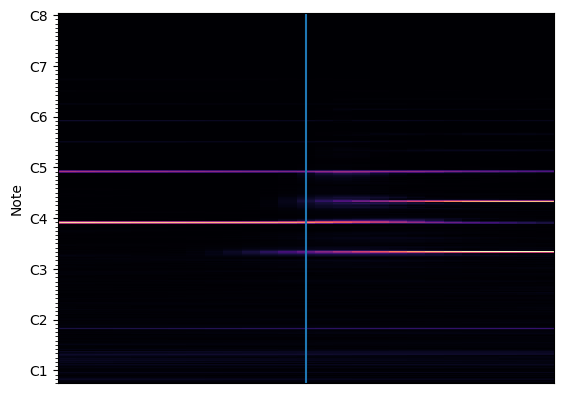

In [46]:
f, ons = files_and_moments[idx]
print(f, librosa.samples_to_time(ons, sr=SR))
ons_frame = librosa.samples_to_frames(ons, hop_length=HOP_LENGTH, n_fft=N_FFT)
delta_f = 13
delta_s = librosa.frames_to_samples(delta_f, hop_length=HOP_LENGTH, n_fft=N_FFT)
y_init, sr_init = librosa.load(f'{midi_dir2}/{f}.mp3')
y_example = librosa.resample(y_init, orig_sr=sr_init, target_sr=SR)

cqt_example = librosa.cqt(y_example, sr=SR, fmin=NOTE_A_MIN, n_bins=N_BINS, bins_per_octave=BINS_PER_OCT,
                          hop_length=HOP_LENGTH)
librosa.display.specshow(cqt_example[:, ons_frame - delta_f : ons_frame + delta_f + 1],
                         fmin=NOTE_A_MIN, bins_per_octave=BINS_PER_OCT, y_axis='cqt_note')
plt.vlines(delta_f, FREQS_CQT[0], FREQS_CQT[FREQS_CQT.shape[0] - 1])
plt.ylim(FREQS_CQT[0], FREQS_CQT[FREQS_CQT.shape[0] - 1])

Audio(y_example[ons - delta_s : ons + delta_s + 1], rate=SR)

/tmp/ipykernel_6964/680636079.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


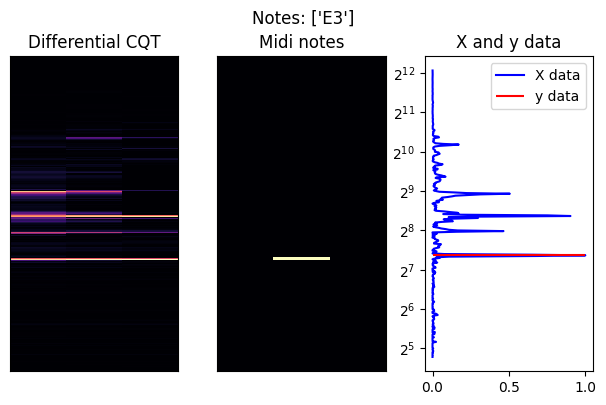

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(6, 4))

img0 = librosa.display.specshow(diff_cqt_data_test[idx].T, ax=axes[0])
img1 = librosa.display.specshow(piano_notes_data_test[idx].T, ax=axes[1])

ax2 = axes[2]
ax2.plot(X_test2[idx], FREQS_CQT, color='blue', label='X data')
ax2.hlines(NOTE_FREQS[np.bool(y_test2[idx])], 0, 1, colors='red', label='y data')
ax2.legend()
ax2.set_yscale('log', base=2)

axes[0].set_title('Differential CQT')
axes[1].set_title('Midi notes')
ax2.set_title('X and y data')

plt.tight_layout(pad=0.2)
fig.suptitle(f'Notes: {np.array(NOTE_NAMES)[np.bool(y_test2[idx])]}')
plt.tight_layout(pad=0.5)
fig.show()

/tmp/ipykernel_6964/2433745200.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=15)


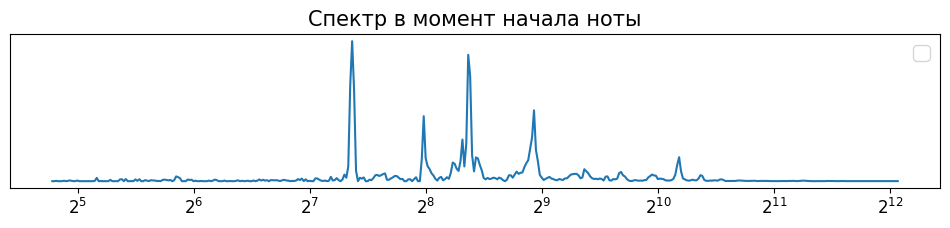

/tmp/ipykernel_6964/2433745200.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=15)


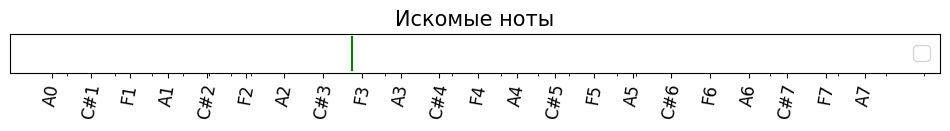

In [ ]:
fig = plt.figure(figsize=(12, 2))
plt.plot(FREQS_CQT, X_test2[idx])
plt.title('Спектр в момент начала ноты', fontsize=15)
fig.axes[0].set_xscale('log', base=2)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=15)
plt.yticks([])
plt.show()

fig = plt.figure(figsize=(12, 0.5))
rng_notes_xaxis = np.int16(np.arange(0, NOTES_COUNT, 4))
plt.vlines(NOTE_FREQS[np.bool(y_test2[idx])], 0, 1, color='green')
plt.scatter(FREQS_CQT, np.zeros_like(FREQS_CQT), alpha=0)
plt.title('Искомые ноты', fontsize=15)
fig.axes[0].set_xscale('log')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=15)
plt.xticks(NOTE_FREQS[rng_notes_xaxis], np.array(NOTE_NAMES)[rng_notes_xaxis], rotation=80)
plt.yticks([])
plt.show()

In [49]:
X_train.shape, X_test.shape, X_test2.shape

((209825, 438), (52457, 438), (3826, 438))

In [50]:
input_shape = list(X_train.shape[1:])

layer2_shape = input_shape + [1]
inp_filters1 = 3
inp_filters2 = 10
pad1 = BINS_PER_OCT

input_shape

[438]

In [51]:
model = models.Sequential([
    layers.InputLayer(input_shape, name='Input_Layer'),
    layers.Dropout(0.02),
    # layers.Reshape(layer2_shape),
    # layers.LocallyConnected1D(2, NOTES_COUNT * 2, activation='relu'),
    # layers.Dropout(0.02),
    # layers.LocallyConnected1D(1, NOTES_COUNT * 2, activation='sigmoid'),
    # layers.Conv1D(5, NOTES_COUNT * 2, activation='relu'),
    # layers.Dropout(0.02),
    # layers.Conv1D(10, NOTES_COUNT * 2, activation='relu'),
    # layers.Dropout(0.02),
    # layers.Reshape([NOTES_COUNT, 10, 1]),
    # layers.LocallyConnected2D(1, (1, 10), activation='sigmoid'),
    # layers.Flatten(),
    layers.Dense(NOTES_COUNT * 3, activation='relu'),
    layers.Dropout(0.02),
    # layers.Dense(NOTES_COUNT * 5, activation='relu'),
    # layers.Dropout(0.02),
    # layers.Dense(NOTES_COUNT * 5, activation='relu'),
    # layers.Dropout(0.05),
    layers.Dense(NOTES_COUNT, activation='sigmoid'),

    # layers.Reshape(layer2_shape),
    # layers.Conv1D(2, BINS_PER_SEMI * 2, padding='same'),
    # layers.MaxPool1D(BINS_PER_SEMI),
    # layers.Conv1D(10, 36),
    # layers.MaxPool1D(2),
    # layers.Conv1D(20, 24),
    # layers.MaxPool1D(2),
    # layers.Flatten(),
    # layers.Dense(NOTES_COUNT, activation='sigmoid'),

    # layers.Reshape(layer2_shape),
    # layers.ZeroPadding2D(padding=((2 + pad1, pad1), (0, 0))),
    # layers.Conv2D(inp_filters2, (pad1 * 2 + 1, HARM_COUNT), activation='relu', name='Conv2D_1', padding='valid'),
    # layers.MaxPool2D((BINS_PER_SEMI, 1)),
    # # layers.Conv2D(inp_filters2, (24, 1), activation='relu', name='Conv2D_2', padding='same'),
    # layers.Reshape((NOTES_COUNT, inp_filters2, 1)),
    # layers.LocallyConnected2D(1, (1, inp_filters2), activation='relu'),
    # layers.Flatten(),
])
model.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=['mse', 'mae'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dropout (Dropout)           (None, 438)               0         
                                                                 
 dense (Dense)               (None, 264)               115896    
                                                                 
 dropout_1 (Dropout)         (None, 264)               0         
                                                                 
 dense_1 (Dense)             (None, 88)                23320     
                                                                 
Total params: 139216 (543.81 KB)
Trainable params: 139216 (543.81 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


E0000 00:00:1778867402.134949    6964 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [60]:
from tf_keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    min_delta=0,
    patience=5,
    verbose=1,
    mode='min',
    restore_best_weights=True
)

In [61]:
np.random.seed(42)
indices = np.arange(y_train.shape[0], dtype=np.int16)
np.random.shuffle(indices)

In [76]:
hist1 = model.fit(
    X_train, y_train, epochs=100, validation_data=[X_test, y_test],
    callbacks=[early_stop]
)

Epoch 1/100
6558/6558 [==============================] - 29s 4ms/step - loss: 0.0370 - mse: 0.0093 - mae: 0.0199 - val_loss: 0.0268 - val_mse: 0.0068 - val_mae: 0.0145
Epoch 2/100
6558/6558 [==============================] - 29s 4ms/step - loss: 0.0252 - mse: 0.0064 - mae: 0.0134 - val_loss: 0.0240 - val_mse: 0.0061 - val_mae: 0.0124
Epoch 3/100
6558/6558 [==============================] - 29s 4ms/step - loss: 0.0224 - mse: 0.0057 - mae: 0.0119 - val_loss: 0.0227 - val_mse: 0.0057 - val_mae: 0.0122
Epoch 4/100
6558/6558 [==============================] - 29s 4ms/step - loss: 0.0205 - mse: 0.0053 - mae: 0.0110 - val_loss: 0.0218 - val_mse: 0.0055 - val_mae: 0.0111
Epoch 5/100
6558/6558 [==============================] - 29s 4ms/step - loss: 0.0191 - mse: 0.0049 - mae: 0.0103 - val_loss: 0.0213 - val_mse: 0.0054 - val_mae: 0.0106
Epoch 6/100
6558/6558 [==============================] - 29s 4ms/step - loss: 0.0180 - mse: 0.0046 - mae: 0.0097 - val_loss: 0.0210 - val_mse: 0.0053 - val_mae:

In [77]:
set(train_test_midi).intersection(test_midi)

set()

In [78]:
model.evaluate(X_test, y_test)

1640/1640 [==============================] - 3s 2ms/step - loss: 0.0208 - mse: 0.0051 - mae: 0.0096


[0.020795704796910286, 0.005134568549692631, 0.00957232154905796]

In [79]:
loss, mae, mse = model.evaluate(X_test2, y_test2)

120/120 [==============================] - 0s 2ms/step - loss: 0.0130 - mse: 0.0033 - mae: 0.0065


/tmp/ipykernel_74950/2761264414.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


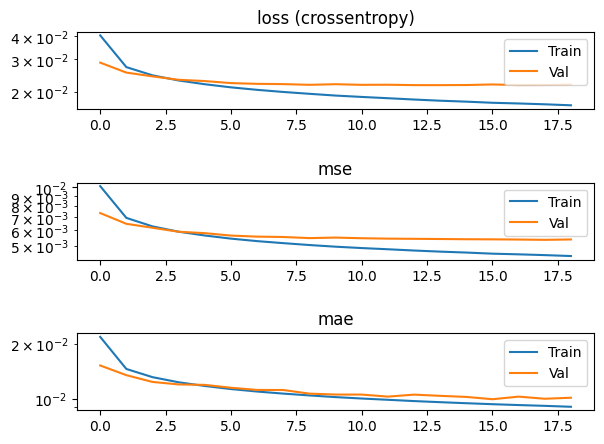

In [ ]:
metrics = list(hist1.history.keys())
cnt = len(metrics) // 2

for hist in [hist1]:

    fig, axes = plt.subplots(cnt, 1)

    for ax, m in zip(axes, metrics[: cnt]):
        ax.plot(hist.history[m], label='Train')
        ax.plot(hist.history['val_' + m], label='Val')
        ax.legend()
        ax.set_yscale('log')
        ax.set_title(m)

    axes[0].set_title('loss (crossentropy)')

    plt.tight_layout(pad=2.0)
    fig.show()

In [52]:
m_path = 'vec2vec_model/model_name v7.keras'

In [53]:
# model.save(m_path)
model = models.load_model(m_path)

In [54]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dropout (Dropout)           (None, 438)               0         
                                                                 
 dense (Dense)               (None, 440)               193160    
                                                                 
 dropout_1 (Dropout)         (None, 440)               0         
                                                                 
 dense_1 (Dense)             (None, 88)                38808     
                                                                 
Total params: 231968 (906.12 KB)
Trainable params: 231968 (906.12 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [55]:
model.evaluate(X_test, y_test)

W0000 00:00:1778867632.837908    6964 cpu_allocator_impl.cc:82] Allocation of 91904664 exceeds 10% of free system memory.


1640/1640 [==============================] - 2s 1ms/step - loss: 0.0218 - mse: 0.0054 - mae: 0.0104


[0.021791113540530205, 0.005409350153058767, 0.010352750308811665]

In [56]:
loss, mae, mse = model.evaluate(X_test2, y_test2)

120/120 [==============================] - 0s 1ms/step - loss: 0.0131 - mse: 0.0034 - mae: 0.0069


In [57]:
pred = model.predict(X_test)

  84/1640 [>.............................] - ETA: 1s

W0000 00:00:1778867636.907319    6964 cpu_allocator_impl.cc:82] Allocation of 91904664 exceeds 10% of free system memory.


1640/1640 [==============================] - 2s 1ms/step


W0000 00:00:1778867639.162243    6964 cpu_allocator_impl.cc:82] Allocation of 18464864 exceeds 10% of free system memory.


In [58]:
pred2 = model.predict(X_test2)

120/120 [==============================] - 0s 1ms/step


In [59]:
from sklearn.metrics import f1_score, precision_score, recall_score, precision_recall_curve
from scipy.stats import hmean

Threshold with max F1 score = 0.42885813


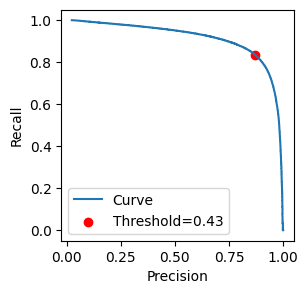

/home/julia/Music/diploma/Rhythm_first_AMT/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


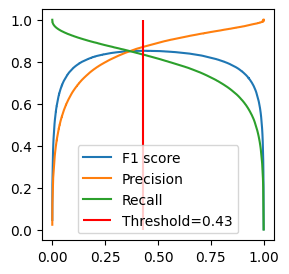

In [60]:
precision, recall, thresholds = precision_recall_curve(y_test.flatten(), pred.flatten())
f1 = hmean(np.array([precision[:-1], recall[:-1]]))

max_idx = np.argmax(f1)
threshold = thresholds[max_idx]
print('Threshold with max F1 score =', threshold)

fig = plt.figure(figsize=(3, 3))
plt.plot(precision, recall, label='Curve')
plt.scatter(precision[max_idx], recall[max_idx], label=f'Threshold={thresholds[max_idx]:.2f}', color='r')
plt.xlabel('Precision')
plt.ylabel('Recall')
plt.legend()
plt.show()

fig = plt.figure(figsize=(3, 3))
plt.plot(thresholds, f1, label='F1 score')
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.vlines(thresholds[max_idx], 0, 1, label=f'Threshold={thresholds[max_idx]:.2f}', color='r')
plt.legend()
plt.show()

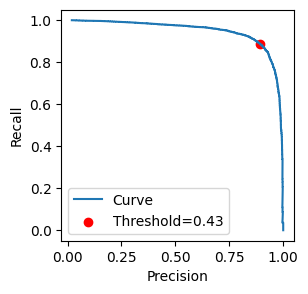

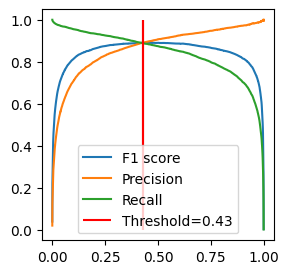

In [61]:
precision, recall, thresholds = precision_recall_curve(y_test2.flatten(), pred2.flatten())
f1 = hmean(np.array([precision[:-1], recall[:-1]]))

t_idx = np.sum(thresholds < threshold)

fig = plt.figure(figsize=(3, 3))
plt.plot(precision, recall, label='Curve')
plt.scatter(precision[t_idx], recall[t_idx], label=f'Threshold={threshold:.2f}', color='r')
plt.xlabel('Precision')
plt.ylabel('Recall')
plt.legend()
plt.show()

fig = plt.figure(figsize=(3, 3))
plt.plot(thresholds, f1, label='F1 score')
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.vlines([thresholds[t_idx], threshold], 0, 1, label=f'Threshold={threshold:.2f}', color='r')
plt.legend()
plt.show()

In [62]:
y_arr = y_test2.copy()
pred_bin = pred2 > threshold

F1 = f1_score(y_arr, pred_bin, average='micro') 
P = precision_score(y_arr, pred_bin, average='micro')
R = recall_score(y_arr, pred_bin, average='micro')

In [63]:
df = pd.DataFrame({
    'loss (crossentropy)': loss, 'mae': mae, 'mse': mse, 
    'F1': F1, 'P': P, 'R': R
}, index=['Vec2vec model']).T
df[df.columns[0]] = df[df.columns[0]].round(3)
df

,Vec2vec model
loss (crossentropy),0.013
mae,0.003
mse,0.007
F1,0.890
P,0.891
R,0.889


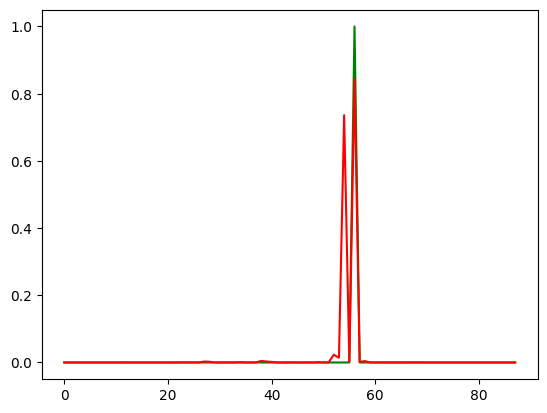

In [64]:
test_idx = np.random.randint(X_test2.shape[0])
plt.plot(y_test2[test_idx], color='green')
plt.plot(pred2[test_idx], color='red')

In [65]:
test_idx2 = idx

/tmp/ipykernel_6964/2095828873.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=15)


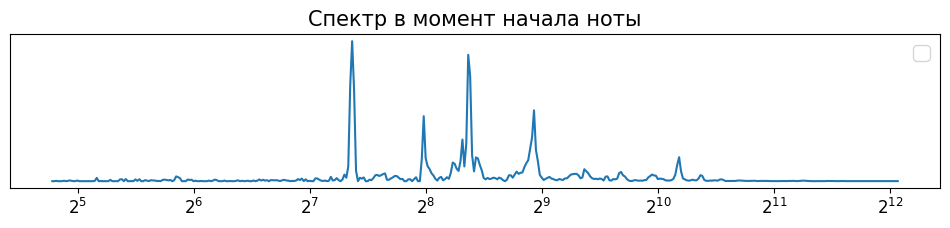

/tmp/ipykernel_6964/2095828873.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=15)


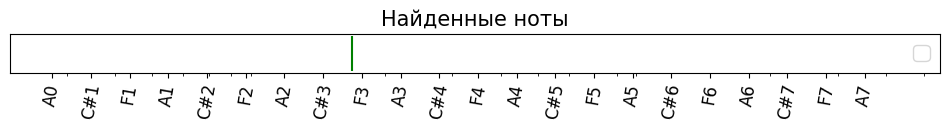

In [67]:
fig = plt.figure(figsize=(12, 2))
plt.plot(FREQS_CQT, X_test2[test_idx2])
plt.title('Спектр в момент начала ноты', fontsize=15)
fig.axes[0].set_xscale('log', base=2)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=15)
plt.yticks([])
plt.show()

fig = plt.figure(figsize=(12, 0.5))
rng_notes_xaxis = np.int16(np.arange(0, NOTES_COUNT, 4))
plt.vlines(NOTE_FREQS[np.bool(pred_bin[test_idx2])], 0, 1, color='green')
plt.scatter(FREQS_CQT, np.zeros_like(FREQS_CQT), alpha=0)
plt.title('Найденные ноты', fontsize=15)
fig.axes[0].set_xscale('log')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=15)
plt.xticks(NOTE_FREQS[rng_notes_xaxis], np.array(NOTE_NAMES)[rng_notes_xaxis], rotation=80)
plt.yticks([])
plt.show()